## Task 1

IMplementing a single artifical neuron. Output is y = sigmoid(wx+b).

Weight and bias are standard normal variables.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed((42))

class Neuron:
    def __init__(self):
        self.weight_matrix = np.random.randn()
        self.bias = np.random.randn()

    def sigmoid(self, x: float):
        return 1 / (1 + np.exp(-x))

    def squared_error(self, y_true: float, y_pred: float):
        return (y_true - y_pred) ** 2

    def output_function(self, x):
        return self.sigmoid(self.weight_matrix * x + self.bias)

    def update(self, x, y_true: float, y_pred: float, eta):
        dE_dy_pred = self.dE_dy_pred(y_true, y_pred)
        dy_pred_dw = self.dy_pred_dw(x, y_pred)
        dy_pred_db = self.dy_pred_db(y_pred)

        dE_dw = dE_dy_pred * dy_pred_dw
        dE_db = dE_dy_pred * dy_pred_db

        self.weight_matrix -= eta * dE_dw
        self.bias -= eta * dE_db

    def dE_dy_pred(self, y_true, y_pred):
        return -2 * (y_true - y_pred)

    def dy_pred_dw(self, x, y_pred):
        return y_pred * (1 - y_pred) * x

    def dy_pred_db(self, y_pred):
        return y_pred * (1 - y_pred)

## Scatterplot before training

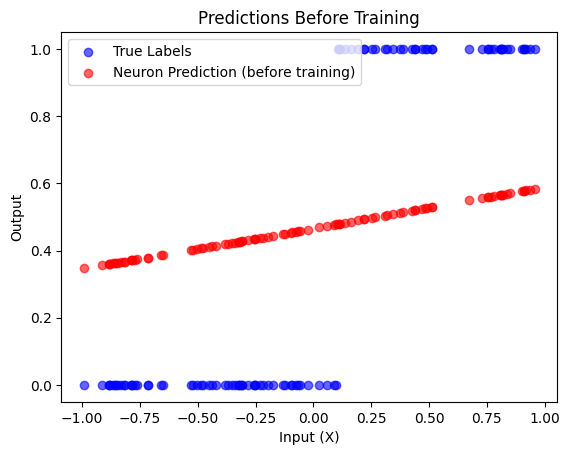

In [2]:


data = np.loadtxt("1d_classification_single_neuron.csv", delimiter=",")
inputs = data[:, 0]
labels = data[:, 1]
neuron = Neuron()
y_pred_before = [neuron.output_function(x) for x in inputs]

plt.scatter(inputs, labels, label="True Labels", color="blue", alpha=0.6)
plt.scatter(inputs, y_pred_before, label="Neuron Prediction (before training)", color="red", alpha=0.6)
plt.xlabel("Input (X)")
plt.ylabel("Output")
plt.legend()
plt.title("Predictions Before Training")
plt.show()



## Implemented training loop

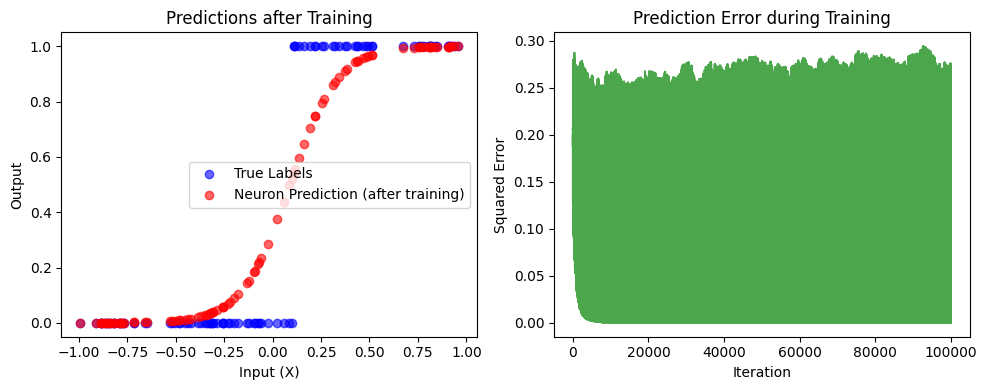

In [3]:

learning_rate = 0.01
n_iterations = 100_000
n_samples = len(inputs)
errors = []
rng = np.random.default_rng()
for i in range(n_iterations):
    idx = rng.integers(n_samples)
    x = inputs[idx]
    y_true = labels[idx]
    y_pred = neuron.output_function(x)
    error = neuron.squared_error(y_true, y_pred)
    errors.append(error)
    neuron.update(x, y_true, y_pred, learning_rate)
y_pred_final = [neuron.output_function(x) for x in inputs]
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(inputs, labels, label="True Labels", color="blue", alpha=0.6)
plt.scatter(
    inputs,
    y_pred_final,
    label="Neuron Prediction (after training)",
    color="red",
    alpha=0.6,
)
plt.xlabel("Input (X)")
plt.ylabel("Output")
plt.legend()
plt.title("Predictions after Training")
plt.subplot(1, 2, 2)
plt.plot(errors, color="green", alpha=0.7)
plt.xlabel("Iteration")
plt.ylabel("Squared Error")
plt.title("Prediction Error during Training")
plt.tight_layout()
plt.show()



## Comments
The prediction graph looks better, especially if we were to have a threshold at around 0.5 and only output boolean values. The prediction error made by the neuron does not decrease as we iterate more.

## Improved learning part (Batched)

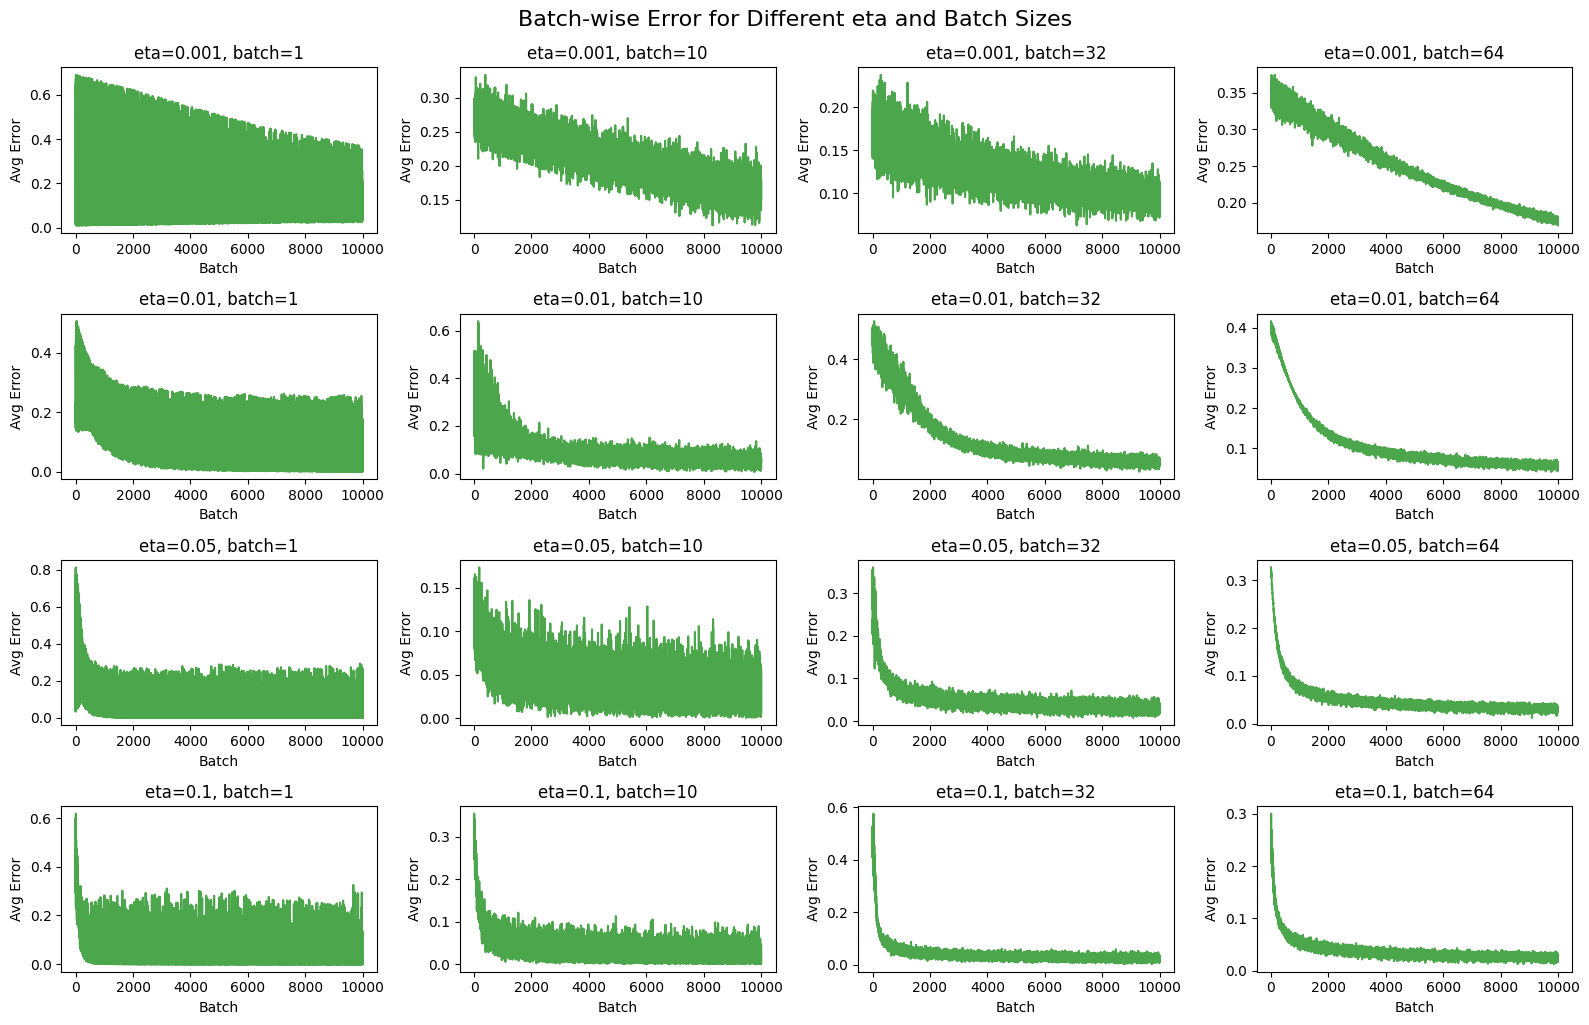

In [4]:
etas = [0.001, 0.01, 0.05, 0.1]
batch_sizes = [1, 10, 32, 64]
n_batches = 10000
n_samples = len(inputs)
rng = np.random.default_rng()
plt.figure(figsize=(16, 10))

for i, eta in enumerate(etas):
    for j, batch_size in enumerate(batch_sizes):
        new_neuron = Neuron()
        errors = []
        for batch in range(n_batches):
            idxs = rng.choice(n_samples, size=batch_size, replace=False)
            batch_x = inputs[idxs]
            batch_y = labels[idxs]
            batch_error = 0
            sum_dE_dw = 0
            sum_dE_db = 0
            for x, y_true in zip(batch_x, batch_y):
                y_pred = new_neuron.output_function(x)
                error = new_neuron.squared_error(y_true, y_pred)
                batch_error += error
                dE_dy_pred = new_neuron.dE_dy_pred(y_true, y_pred)
                dy_pred_dw = new_neuron.dy_pred_dw(x, y_pred)
                dy_pred_db = new_neuron.dy_pred_db(y_pred)
                sum_dE_dw += dE_dy_pred * dy_pred_dw
                sum_dE_db += dE_dy_pred * dy_pred_db
            avg_dE_dw = sum_dE_dw / batch_size
            avg_dE_db = sum_dE_db / batch_size
            new_neuron.weight_matrix -= eta * avg_dE_dw
            new_neuron.bias -= eta * avg_dE_db
            errors.append(batch_error / batch_size)
        plt.subplot(len(etas), len(batch_sizes), i * len(batch_sizes) + j + 1)
        plt.plot(errors, color="green", alpha=0.7)
        plt.title(f"eta={eta}, batch={batch_size}")
        plt.xlabel("Batch")
        plt.ylabel("Avg Error")
        plt.tight_layout()
plt.suptitle("Batch-wise Error for Different eta and Batch Sizes", fontsize=16, y=1.02)
plt.show()

## Comments

We can see that higher batch sizes leads to lower average error, in general a higher learning rate combined with the increased batch size also leads to lower fluctiations.